# Faster R-CNN — Anchor Analysis

Analyses the GT bounding box distribution in the training set to identify
whether the default Faster R-CNN anchors are well-matched to LARS.

**Outputs:** recommended `anchor_sizes` and `aspect_ratios` to pass to the RPN.

In [8]:
from pathlib import Path

DATA_ROOT  = Path("../Data/lars_processed")
SPLIT      = "train"          # anchor tuning always uses the training set
N_CLUSTERS = 9                # total anchors = N_CLUSTERS (will be factored into sizes × ratios)

# Current torchvision defaults (one tuple per FPN level P2-P6)
DEFAULT_SIZES  = (32, 64, 128, 256, 512)   # sqrt(area) in pixels
DEFAULT_RATIOS = (0.5, 1.0, 2.0)           # height/width

In [9]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

ann         = json.load(open(DATA_ROOT / SPLIT / "_annotations.coco.json"))
categories  = ann["categories"]
CLASS_NAMES = [c["name"] for c in categories]
id_to_name  = {c["id"]: c["name"] for c in categories}
id_to_idx   = {c["id"]: i for i, c in enumerate(categories)}

boxes = np.array([[a["bbox"][2], a["bbox"][3], a["category_id"]]
                  for a in ann["annotations"]], dtype=float)  # [w, h, cat_id]

# Remove degenerate boxes (w or h < 1px)
boxes = boxes[(boxes[:, 0] >= 1) & (boxes[:, 1] >= 1)]

wh      = boxes[:, :2]          # (N, 2)
areas   = wh[:, 0] * wh[:, 1]
ratios  = wh[:, 1] / wh[:, 0]  # h/w
cat_ids = boxes[:, 2].astype(int)

print(f"Training annotations : {len(wh)}")
print(f"Width  — min:{wh[:,0].min():.0f}  median:{np.median(wh[:,0]):.0f}  max:{wh[:,0].max():.0f}")
print(f"Height — min:{wh[:,1].min():.0f}  median:{np.median(wh[:,1]):.0f}  max:{wh[:,1].max():.0f}")
print(f"Area   — min:{areas.min():.0f}  median:{np.median(areas):.0f}  max:{areas.max():.0f}")
print(f"\nDefault smallest anchor size : {DEFAULT_SIZES[0]}px")
pct_below = (np.sqrt(areas) < DEFAULT_SIZES[0]).mean() * 100
print(f"GT boxes with sqrt(area) < {DEFAULT_SIZES[0]}px : {pct_below:.1f}%  ← missed by default anchors")

Training annotations : 8025
Width  — min:1  median:27  max:1711
Height — min:1  median:18  max:1089
Area   — min:1  median:468  max:886764

Default smallest anchor size : 32px
GT boxes with sqrt(area) < 32px : 61.0%  ← missed by default anchors


## 1. Size and aspect ratio distribution

/tmp/ipykernel_862163/200640514.py:30: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", len(categories))


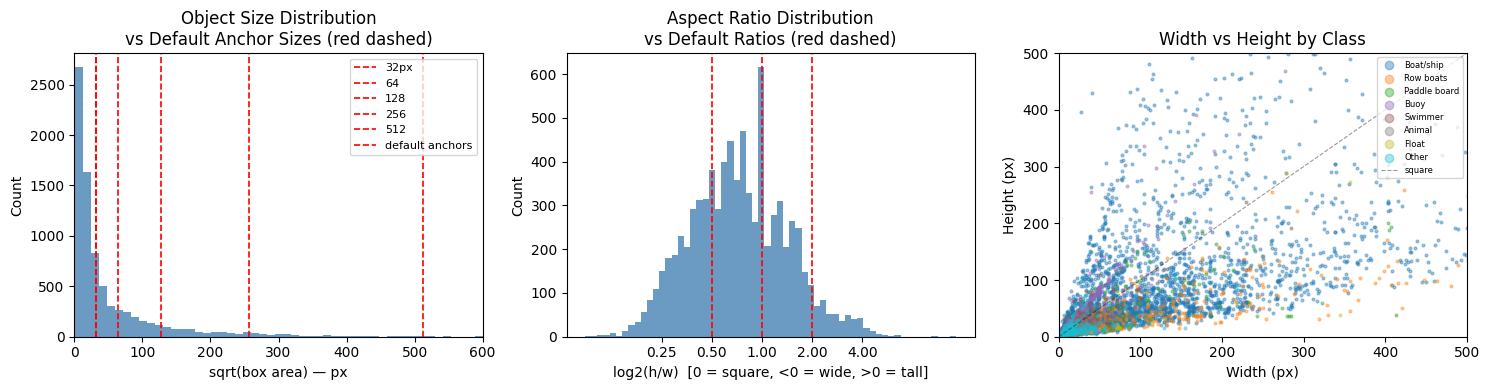

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# ── Area distribution with default anchor sizes overlaid ─────────────────────
ax = axes[0]
sqrt_areas = np.sqrt(areas)
ax.hist(sqrt_areas, bins=80, color="steelblue", alpha=0.8, edgecolor="none")
for s in DEFAULT_SIZES:
    ax.axvline(s, color="red", linestyle="--", linewidth=1.2, label=f"{s}px" if s == DEFAULT_SIZES[0] else s)
ax.axvline(DEFAULT_SIZES[0], color="red", linestyle="--", linewidth=1.2, label="default anchors")
ax.set_xlabel("sqrt(box area) — px")
ax.set_ylabel("Count")
ax.set_title("Object Size Distribution\nvs Default Anchor Sizes (red dashed)")
ax.set_xlim(0, 600)
ax.legend(fontsize=8)

# ── Aspect ratio distribution ─────────────────────────────────────────────────
ax = axes[1]
ax.hist(np.log2(ratios), bins=60, color="steelblue", alpha=0.8, edgecolor="none")
for r in DEFAULT_RATIOS:
    ax.axvline(np.log2(r), color="red", linestyle="--", linewidth=1.2)
ax.set_xlabel("log2(h/w)  [0 = square, <0 = wide, >0 = tall]")
ax.set_ylabel("Count")
ax.set_title("Aspect Ratio Distribution\nvs Default Ratios (red dashed)")
ticks = [-2, -1, 0, 1, 2]
ax.set_xticks(ticks)
ax.set_xticklabels([f"{2**t:.2f}" for t in ticks])

# ── W vs H scatter coloured by class ────────────────────────────────────────
ax = axes[2]
cmap = plt.cm.get_cmap("tab10", len(categories))
for i, cat in enumerate(categories):
    mask = cat_ids == cat["id"]
    ax.scatter(wh[mask, 0], wh[mask, 1], s=4, alpha=0.4,
               color=cmap(i), label=cat["name"])
ax.set_xlabel("Width (px)"); ax.set_ylabel("Height (px)")
ax.set_title("Width vs Height by Class")
ax.set_xlim(0, 500); ax.set_ylim(0, 500)
ax.plot([0, 500], [0, 500], "k--", linewidth=0.8, alpha=0.4, label="square")
ax.legend(fontsize=6, markerscale=3)

plt.tight_layout()
plt.savefig("../runs/fasterrcnn/anchor_analysis_dist.png", dpi=130, bbox_inches="tight")
plt.show()

## 2. Per-class size summary

In [11]:
print(f"{'Class':<18} {'Count':>6} {'Median W':>9} {'Median H':>9} {'Median √A':>10} {'Median h/w':>11}")
print("-" * 68)
for cat in categories:
    mask = cat_ids == cat["id"]
    if mask.sum() == 0:
        continue
    mw  = np.median(wh[mask, 0])
    mh  = np.median(wh[mask, 1])
    msa = np.median(np.sqrt(areas[mask]))
    mr  = np.median(ratios[mask])
    print(f"{cat['name']:<18} {mask.sum():>6} {mw:>9.1f} {mh:>9.1f} {msa:>10.1f} {mr:>11.2f}")

Class               Count  Median W  Median H  Median √A  Median h/w
--------------------------------------------------------------------
Boat/ship            5100      40.0      25.0       31.0        0.64
Row boats             379      66.0      30.0       45.5        0.40
Paddle board          125      72.0      40.0       60.3        0.64
Buoy                 1350       8.9       9.0        9.0        1.00
Swimmer               275      17.0      15.0       15.2        0.92
Animal                357      14.0       8.0       11.0        0.66
Float                  21      83.0      24.0       44.6        0.26
Other                 418      12.6      10.0       11.0        0.93


## 3. K-means anchor clustering

Uses IoU-based distance (the YOLO approach) rather than Euclidean distance,
since box dimensions scale multiplicatively. Clusters `N_CLUSTERS` anchor shapes
then factors them into sizes × aspect ratios for the Faster R-CNN API.

In [12]:
def iou_distance(boxes_wh, anchors_wh):
    """IoU between each box and each anchor, both centred at origin."""
    # boxes_wh : (N, 2),  anchors_wh : (K, 2)
    inter_w = np.minimum(boxes_wh[:, None, 0], anchors_wh[None, :, 0])
    inter_h = np.minimum(boxes_wh[:, None, 1], anchors_wh[None, :, 1])
    inter   = inter_w * inter_h
    area_b  = boxes_wh[:, 0]   * boxes_wh[:, 1]
    area_a  = anchors_wh[:, 0] * anchors_wh[:, 1]
    union   = area_b[:, None] + area_a[None, :] - inter
    return 1.0 - inter / np.maximum(union, 1e-10)


def kmeans_anchors(wh, k, seed=4, max_iter=300):
    np.random.seed(seed)
    anchors = wh[np.random.choice(len(wh), k, replace=False)].copy()
    for _ in range(max_iter):
        dist    = iou_distance(wh, anchors)
        labels  = dist.argmin(axis=1)
        new_anchors = np.array([wh[labels == j].mean(axis=0)
                                if (labels == j).any() else anchors[j]
                                for j in range(k)])
        if np.allclose(new_anchors, anchors, atol=0.5):
            break
        anchors = new_anchors
    avg_iou = (1 - dist.min(axis=1)).mean()
    return anchors, avg_iou


clusters, avg_iou = kmeans_anchors(wh, N_CLUSTERS)
clusters = clusters[clusters[:, 0].argsort()]  # sort by width

print(f"K-means anchors (k={N_CLUSTERS}, avg IoU with nearest anchor = {avg_iou:.3f})")
print(f"{'#':<4} {'W':>7} {'H':>7} {'sqrt(A)':>9} {'h/w':>7}")
print("-" * 38)
for i, (w, h) in enumerate(clusters):
    print(f"{i:<4} {w:>7.1f} {h:>7.1f} {np.sqrt(w*h):>9.1f} {h/w:>7.2f}")

K-means anchors (k=9, avg IoU with nearest anchor = 0.542)
#          W       H   sqrt(A)     h/w
--------------------------------------
0        8.3     7.1       7.7    0.85
1       28.9    18.1      22.9    0.63
2       61.0    44.7      52.2    0.73
3       81.7   161.4     114.8    1.97
4      155.8    62.1      98.4    0.40
5      207.9   404.6     290.0    1.95
6      260.2   123.9     179.5    0.48
7      485.2   210.3     319.4    0.43
8      775.0   505.9     626.1    0.65


## 4. Recommended anchor configuration

In [15]:
## 4. Recommended anchor configuration (Grouped for 5-Level FPN)
sqrt_areas_cl = np.sqrt(clusters[:, 0] * clusters[:, 1])
ratios_cl     = clusters[:, 1] / clusters[:, 0]

# 1. Get all original GPU-friendly sizes (usually ~9 sizes)
all_sizes = sorted(set(int(round(s / 8) * 8) for s in sqrt_areas_cl))

# 2. Distribute the sizes across 5 FPN levels (P2 to P6)
fpn_sizes = [[] for _ in range(5)]
for i, s in enumerate(all_sizes):
    # This mathematically maps index 'i' into 5 buckets
    idx = min(i * 5 // len(all_sizes), 4)
    fpn_sizes[idx].append(s)

# Convert to a tuple of tuples: e.g., ((8, 24), (56, 96), (112, 176), (288, 320), (624,))
rec_sizes = tuple(tuple(g) for g in fpn_sizes)

# 3. Keep 3 representative ratios
rec_ratios = tuple(sorted(set(round(r * 4) / 4 for r in np.percentile(ratios_cl, [20, 50, 80]))))

print("── Recommended anchor config for train_fasterrcnn.py ──────────────────")
print()
print("anchor_sizes = (")
for i, level_sizes in enumerate(rec_sizes, start=2):
    print(f"    {level_sizes},  # P{i}")
print(")")
print(f"aspect_ratios = {rec_ratios}")
print()
print("Pass to build_model() via the RPN:")
print("    from torchvision.models.detection.rpn import AnchorGenerator")
print("    anchor_gen = AnchorGenerator(")
print("        sizes=anchor_sizes,")
print(f"        aspect_ratios=({rec_ratios},) * 5,") 
print("    )")
print("    model.rpn.anchor_generator = anchor_gen")
print()

# ── Coverage comparison ──────────────────────────────────────────────────────
def coverage_grouped(wh_data, grouped_sizes, ratios, iou_thresh=0.5):
    """Flatten the grouped sizes to calculate IoU coverage."""
    flat_sizes = [s for group in grouped_sizes for s in group]
    anchors = np.array([[s / np.sqrt(r), s * np.sqrt(r)]
                        for s in flat_sizes for r in ratios])
    dist    = iou_distance(wh_data, anchors)
    return (dist.min(axis=1) <= (1 - iou_thresh)).mean()

# Note: We use coverage_grouped for the tuned sizes, and standard for default
def coverage(wh_data, sizes, ratios, iou_thresh=0.5):
    anchors = np.array([[s / np.sqrt(r), s * np.sqrt(r)]
                        for s in sizes for r in ratios])
    dist    = iou_distance(wh_data, anchors)
    return (dist.min(axis=1) <= (1 - iou_thresh)).mean()

cov_default = coverage(wh, DEFAULT_SIZES, DEFAULT_RATIOS)
cov_tuned   = coverage_grouped(wh, rec_sizes, rec_ratios)
print(f"GT box coverage (IoU>=0.5):")
print(f"  Default anchors : {cov_default:.1%}")
print(f"  Tuned anchors   : {cov_tuned:.1%}")

── Recommended anchor config for train_fasterrcnn.py ──────────────────

anchor_sizes = (
    (8, 24),  # P2
    (56, 96),  # P3
    (112, 176),  # P4
    (288, 320),  # P5
    (624,),  # P6
)
aspect_ratios = (0.5, 0.75, 1.25)

Pass to build_model() via the RPN:
    from torchvision.models.detection.rpn import AnchorGenerator
    anchor_gen = AnchorGenerator(
        sizes=anchor_sizes,
        aspect_ratios=((0.5, 0.75, 1.25),) * 5,
    )
    model.rpn.anchor_generator = anchor_gen

GT box coverage (IoU>=0.5):
  Default anchors : 45.6%
  Tuned anchors   : 66.6%


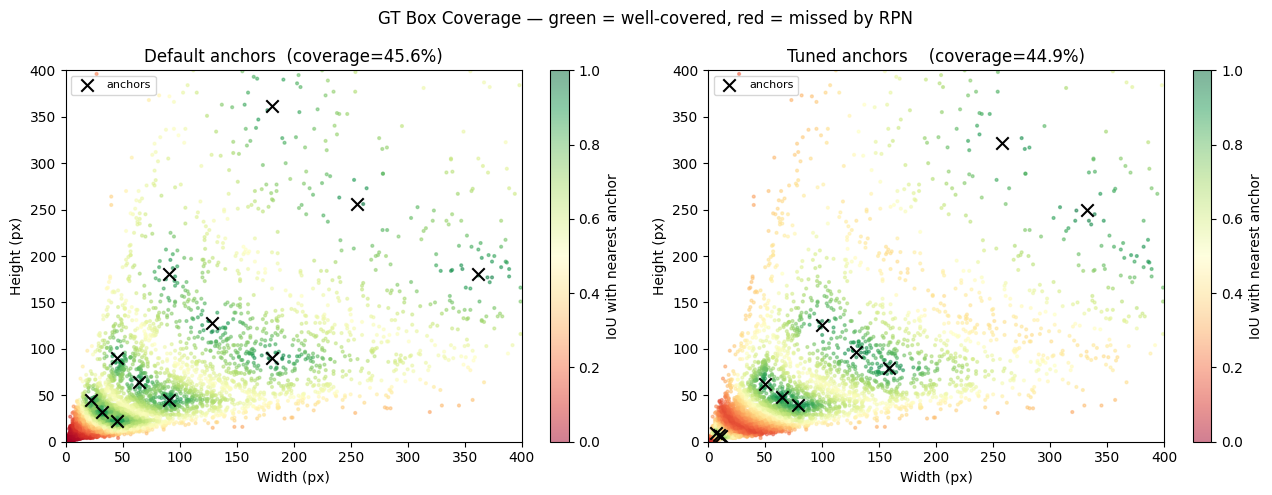

In [14]:
# Visual: GT boxes vs default and tuned anchors in W/H space
def anchor_boxes(sizes, ratios):
    return np.array([[s / np.sqrt(r), s * np.sqrt(r)] for s in sizes for r in ratios])

def nearest_iou(wh_data, sizes, ratios):
    anchors = anchor_boxes(sizes, ratios)
    return 1 - iou_distance(wh_data, anchors).min(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (sizes, ratios, title) in zip(axes, [
    (DEFAULT_SIZES, DEFAULT_RATIOS, f"Default anchors  (coverage={cov_default:.1%})"),
    (rec_sizes,     rec_ratios,     f"Tuned anchors    (coverage={cov_tuned:.1%})"),
]):
    iou_vals = nearest_iou(wh, sizes, ratios)
    sc = ax.scatter(wh[:, 0], wh[:, 1], c=iou_vals, cmap="RdYlGn",
                    vmin=0, vmax=1, s=4, alpha=0.5)
    anc = anchor_boxes(sizes, ratios)
    ax.scatter(anc[:, 0], anc[:, 1], marker="x", s=80, color="black",
               linewidths=1.5, zorder=5, label="anchors")
    ax.set_xlim(0, 400); ax.set_ylim(0, 400)
    ax.set_xlabel("Width (px)"); ax.set_ylabel("Height (px)")
    ax.set_title(title)
    ax.legend(fontsize=8)
    plt.colorbar(sc, ax=ax, label="IoU with nearest anchor")

plt.suptitle("GT Box Coverage — green = well-covered, red = missed by RPN", fontsize=12)
plt.tight_layout()
plt.savefig("../runs/fasterrcnn/anchor_analysis_coverage.png", dpi=130, bbox_inches="tight")
plt.show()